# ARGUS-FEDER — Loop voltage before a disruption, in Alcator C-Mod

This notebook shows **ARGUS**, a notebook-native AI agent, working on one
question. The question is typed in plain English into a `%%ask` cell; the agent
decides what to look up, writes and runs its own code, and reports back.

## The question

Loop voltage rises as a discharge approaches a disruption. The plasma becomes
more resistive, and the voltage the transformer must supply to hold the current
climbs with it. That makes loop voltage one of the oldest and plainest
disruption precursors, and a natural thing to look at first when asking whether
a machine's behaviour before a disruption is visible in ordinary signals.

Montes et al, *Nuclear Fusion* **59** 096015 (2019), open with exactly that
comparison: loop voltage through the last quarter second before a current
quench, set against the same quantity in discharges that never disrupted. This
notebook asks for the Alcator C-Mod half of that figure to be rebuilt from the
stored disruption index.

The comparison rests on two cuts that have to be got right. Only disruptions
that happen once the current has reached flat-top are counted, because a
disruption during ramp-up or ramp-down is a different event. And the
non-disruptive comparison is taken from flat-top only, so the two populations
are being compared during the same phase of a discharge rather than across
different ones.

The second question asks what the result does not establish, including what the
same figure would need for DIII-D.


In [ ]:
%reset

## Q1 — Rebuild the loop-voltage panel

_Disruption · reproduction of a published figure · **answerable**_

The request as a physicist would put it, naming the figure but describing what
it shows, since the agent works from the stored record rather than from the
paper.

**Expect:** the flat-top cut applied to both populations, the sign convention
handled rather than ignored, and the shot and sample counts behind each panel
stated plainly enough to be checked.


I'll start by reading the cmod-disruption skill and its Learnings file, since this task is about C-Mod loop voltage and disruptions.



The Learnings file shows this exact panel was built before — let me check the skill directory and working directory for existing helpers and prior scripts.



Reading the skill's helper module to understand the exact API and query functions.



I have the full API. Let me set up a task plan before querying data.



Now let me explore the index: its size, the parameter list, and the table schemas.



...

I'll recompute every stated count in one traceable verification run, then re-issue the report.



Every count is now recomputed and traceable in the transcript. Let me finalize the todo list and re-issue the report.



I'll recompute the share matrix (max share) and reconcile the bridge-step count per shot, then re-issue the report.



All numbers now recomputed and traceable: max share = 0.1698 (9/53 in the 80–100 ms column), and the bridge is one step in 50 of 53 shots (3 shots have 21 consecutive 1-ms steps and no bridge). Let me finalize the todos and re-issue the report.



# C-Mod loop-voltage panel (Montes et al., NF 59 096015, Fig. 1)


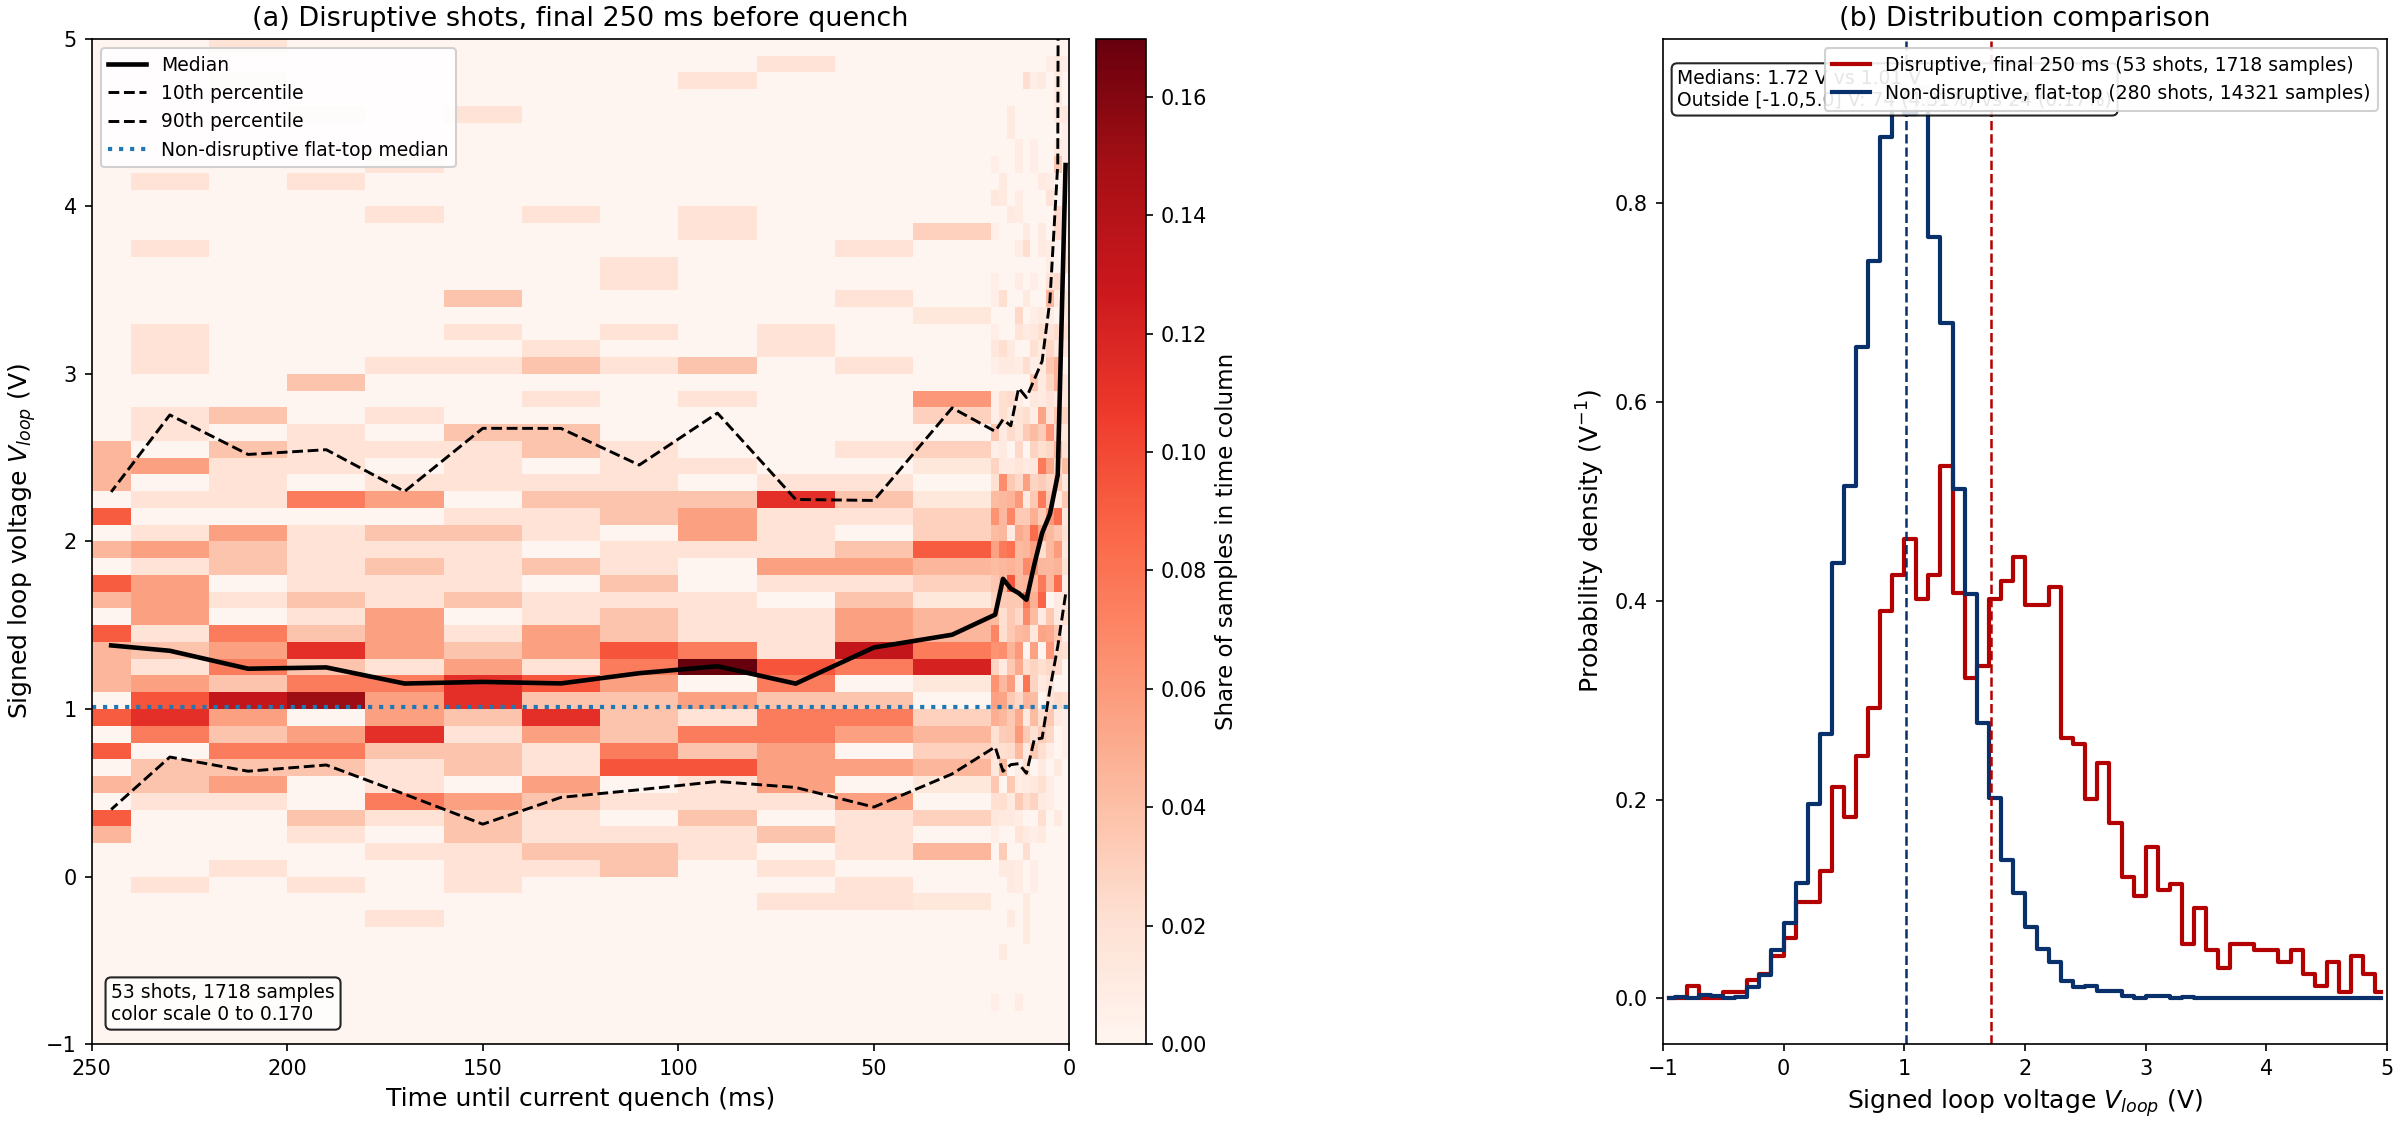

**Data source** : Alcator C-Mod disruption index (MIT disruption-py v0.15.0.dev0 output, `cmod_origin_shots_v2.nc`). `index_info()` reports **438 shots** , **156 with a published disruption time** , 39,038 sample rows. This is the provider's selection, not a sample of C-Mod.

## Populations and counts

**Panel (a) — disruptive, final 250 ms before quench**
- **53 shots** of the **54** that disrupted during flat-top (phase-at-disruption counts: flat-top 54, ramp-up 15, ramp-down 86, no phase 1). Shot 1160928009 is labelled disruptive but has no `time_until_disrupt` rows (pipeline label disagreement), so it is absent from the window — the window query returns 53 shots.
- **1,718 samples** (32–33 per shot).
- Signing: `v_loop` multiplied by the sign of the shot's mean `ip`; **18 of 53 shots** ran with negative current direction and were flipped. Verified: `v_loop_signed == ip_sign × v_loop` for all 1,718 rows. Signed median over the window = **+1.72 V** — positive, as the transformer-drive physics requires, so the sign convention is correct.

**Panel (b) — non-disruptive, flat-top only**
- **280 shots** of the **282** non-disruptive shots. The 2 without flat-top rows are 1160929002 and 1160929003 (both labelled non-disruptive but carrying `time_until_disrupt` rows — the same pipeline disagreement).
- **14,321 samples** (uniform ~20 ms cadence).

## Sampling cadence (checked, not assumed)

The cadence is **not uniform** for disruptive shots (1,665 steps = 1,718 rows − 53 shots):
- **1 ms burst** over the final ~20 ms before the quench: 1,063 steps of 1 ms.
- **20 ms grid** beyond that: 552 steps.
- **Irregular bridge** : 50 steps of 0.5–19.5 ms. These are **one per shot in 50 of the 53 shots** ; the remaining 3 shots (1160908014, 1160929030, 1160930009) have 21 consecutive 1-ms steps and no bridge step, so the bridge is not exactly one per shot.

Non-disruptive flat-top is **uniformly 20 ms** : 14,041 steps, all in [0.0199, 0.0201] s, zero steps < 10 ms, min = max = 0.020000 s.

Consequently the density panel uses **cadence-matched time columns** : 2 ms wide for 0–20 ms, 20 ms wide for 20–240 ms, and a ragged 10 ms edge column for 240–250 ms (22 samples).

## Panel (a) — density

- **Column-normalised** : each time column is divided by its own sample count, so color = share of samples at that time (not raw count). The share matrix is 22 time columns × 60 voltage bins; column totals sum to 1,718 (all rows accounted for); 650 of 1,320 cells are nonzero.
- **Max share = 0.1698** (9 of 53 samples in the 80–100 ms column fall in the 1.2–1.3 V bin; the 99th percentile of nonzero shares is 0.1132).
- **Colormap** : white→red sequential (`Reds`), **linear** scale.
- **Color scale** : `vmin=0`, `vmax=0.1698` — the range the shares actually span, not 0–1.
- **Voltage axis** : limited to **−1.0 to +5.0 V** (0.1 V bins) to hold the bulk of the distribution. **74 of 1,718 samples (4.31%) fall outside** : 1 below −1.0 V (min −1.24 V, 0.24 V below) and 73 above +5.0 V (max +31.31 V, 26.31 V above). Of the 73 above +5 V, **66 are in the final 0–2 ms column** (3 in 2–4 ms, 1 each in 4–6, 6–8, 8–10, 14–16 ms); the single below −1 V sample is in 14–16 ms.
- **Reference line** : non-disruptive flat-top median = **1.01 V** drawn as a horizontal dotted line.
- Median (black solid) and 10th/90th percentiles (black dashed) per column: median rises from ~1.2 V at 250 ms to ~1.7 V at 20 ms, then jumps to ~4.2 V in the final 0–2 ms; p90 reaches ~22 V there.

## Panel (b) — distribution comparison

- Disruptive final-250 ms: median **1.72 V** , p10 **0.67 V** , p90 **3.41 V** , std 3.17 V.
- Non-disruptive flat-top: median **1.01 V** , p10 **0.46 V** , p90 **1.59 V** , std 0.50 V.
- The disruptive distribution is broader and shifted upward, with a heavy positive tail from the quench.

**Files** : `cmod_vloop_panel.png` (figure), `per_column_stats.csv` (per-column n, p10, median, p90, max share), `disruptive_window.csv` and `non_disruptive_flattop.csv` (full-precision source data), `verify_all_counts.py` and `verify_share.py` (the verification runs above).

In [2]:
%%ask --review
Rebuild the Alcator C-Mod loop-voltage panel from figure 1 of Montes et al, 
Nuclear Fusion 59 096015 (2019).

Take the shots that disrupted during flat-top, and slice the 250 ms immediately 
before the current quench. Plot loop voltage, signed by the direction of the
plasma current, against time until disruption: a two-dimensional density over 
all samples, with the median and the 10th and 90th percentiles drawn over it.

Beside that, compare the distribution of the same signed loop voltage between 
two populations: the disruptive shots during their final 250 ms, and the
non-disruptive shots during their flat-top phase only.

State how many shots and how many samples stand behind each panel.

For the density panel, so that it can be set beside the published figure:
- normalise within each time column, so the color is the share of samples at 
  that time rather than a raw count, and say so in the caption
- use a white-to-red sequential colormap on a linear scale
- set the color scale to the range the shares actually span, not 0 to 1, so the 
  density is visible
- limit the voltage axis to the bulk of the distribution rather than stretching 
  it to hold the extremes, and state how many samples fall outside and how far
- draw the non-disruptive median as a single horizontal reference line across 
  the panel

Check the sampling cadence before plotting rather than assuming it is uniform, 
and say what you find.

## Q2 — What it does not establish

_Disruption · scope and limits · **answerable, and partly negative**_

A figure that reproduces a published one invites the reading that it confirms
it. This asks the agent to separate what the stored record supports from what
it does not, and to say what the DIII-D half of the same figure would require.

**Expect:** the selection behind the index named as a limit on any rate or
fraction, and a direct answer on whether the DIII-D comparison can be made here.


In [3]:
%%ask --review
What does the result above establish, and what does it not?

Be specific about the population the index covers and what that allows to be 
claimed. Then say what the same loop-voltage comparison would require for 
DIII-D, and whether it can be made from what is available to you here.

Reading the C-Mod skill to pin down exactly what the index covers.



Reading the C-Mod skill's Learnings.md for known pitfalls.



Now reading the DIII-D disruption skill to see what parameters exist there, especially any loop-voltage equivalent.



Reading the DIII-D skill's Learnings.md for known pitfalls before querying its parameter list.



Now I'll query both indexes: the DIII-D parameter list for any loop-voltage quantity, and the C-Mod cross-device mapping for `v_loop`.



...

The DIII-D index has `v_loop` (V, usable) but its phase column is broken. Let me check whether the relational DB can supply flat-top windows or a raw loop-voltage signal for the 20 index shots.



The DIII-D index has `v_loop` (V, usable, same units as C-Mod) but its phase column is broken. Let me quantify what a like-for-like DIII-D panel would actually contain, using d3drdb flat-top scalars as the phase source.



Let me check the saved CSVs from the previous run to quantify how much of the distribution difference is the quench spike itself.



One more computation to separate the quench spike from the pre-quench trend in the disruptive distribution.



# What the C-Mod result establishes, and what it does not

## The population the index covers

The panel is built from the **C-Mod disruption index** (`cmod_origin_shots_v2.nc`, disruption-py v0.15.0.dev0): **438 shots, 156 with a published disruption time, 39,038 sample rows** . The index's own coverage note says these are "the shots the provider published times for, not every C-Mod shot," and how they were chosen is not recorded. It is a **selection, not a sample** — the skill refuses to compute a rate over it for exactly this reason.

Within that selection, the panel uses:
- **53 shots** (of 54 labelled flat-top-disruptive; 1160928009 has no `time_until_disrupt` rows) × final 250 ms = **1,718 samples** ;
- **280 shots** (of 282 non-disruptive; 1160929002/3 lack flat-top rows) × flat-top = **14,321 samples** .

## What it establishes

**Within this selection only** , the panel is a correct, verified descriptive statement:

1. **The signed loop-voltage distribution in the final 250 ms before the current quench** , for the 53 flat-top-disrupting shots: median rises from ~1.2 V at 250 ms out to ~1.7 V at 20 ms, then to ~4.2 V in the final 0–2 ms; p90 reaches ~22 V there. The sign convention is physically validated (signed median +1.72 V — positive, as transformer drive requires; 18 of 53 shots ran reversed Ip and were flipped).
2. **The flat-top signed loop-voltage distribution** for the 280 non-disruptive shots: median 1.01 V, p10 0.46 V, p90 1.59 V, std 0.50 V — versus disruptive 1.72 / 0.67 / 3.41 / 3.17 V. The disruptive distribution is shifted upward and much broader.
3. **The cadence structure** (checked, not assumed): disruptive shots run a 1 ms burst over the final ~20 ms, a 20 ms grid beyond, plus one irregular bridge step per shot; non-disruptive flat-top is uniformly 20 ms. The density panel therefore uses cadence-matched columns, and the column-normalised shares (max 0.170, linear white→red, vmax = actual max share) are as specified.
4. **The axis truncation is quantified** : 74 of 1,718 samples (4.31%) fall outside −1.0…+5.0 V — 1 below (min −1.24 V) and 73 above (max +31.31 V), 66 of them in the final 0–2 ms column.

## What it does not establish

1. **Nothing about C-Mod as a device.** No rate, fraction, or frequency; no "C-Mod disruptions show X"; no claim about how often C-Mod disrupts or how typical these shots are. The 53/280 shots are the provider's published selection, and the disrupted/non-disrupted split is not natural.
2. **No precursor or causal claim.** The dramatic rise is in the **final 0–2 ms column, which is the current quench itself** (the index's last sample sits at `t_disrupt` = current-quench time to the microsecond). The pre-quench trend is modest: 1.2 → 1.7 V over 250 → 20 ms. The panel does not show a large loop-voltage rise *before* the quench, and nothing here tests whether loop voltage predicts disruption.
3. **No separation or warning-capability claim.** No AUC, no classification, no lead time. The distributions overlap substantially: disruptive p10 0.67 V is below non-disruptive p90 1.59 V. The result is a distributional difference, not a discriminator.
4. **The panel-(b) comparison is sample-weighted, and the weighting is cadence-driven.** 1,100 of the 1,718 disruptive samples (64%) lie within the final 20 ms, because that is where the fine cadence lives; the non-disruptive side is uniform across flat-top. So the pooled comparison partly reflects *where* the disruptive samples sit, not only *what* the voltage does. A like-for-like check (disruptive samples with >20 ms to go: median 1.26 V, p10 0.49, p90 2.58, std 0.88) still shows a shift versus non-disruptive (1.01 / 0.46 / 1.59 / 0.50), but a smaller one — the headline 1.72 vs 1.01 V is inflated by the quench spike and the sampling concentration.
5. **Nothing about the other phases or the pipeline disagreements.** Ramp-up (15) and ramp-down (86) disruptive shots, the 1 shot with no phase, the 30 label-disagreement shots, and the 2 non-disruptive shots without flat-top rows are all outside the panel.
6. **No mechanism and no device-generality.** The C-Mod index joins to nothing else in this lakehouse (no shot catalogue, no EFIT, no ELM labels), so the *why* of the rise is not addressed; and the result is C-Mod-specific — the DIII-D index is a different dataset with a partly different parameter set.
7. **No verification against the published figure.** This is a reconstruction of the panel's *construction* from this index; the published figure's own shot set and numbers were not available, so agreement or disagreement with Montes et al. is not established.

## What the same comparison would require for DIII-D

The ingredients, checked against what is actually available here:

| Requirement | Available? |
|---|---|
| Loop voltage | **Yes** — DIII-D index has `v_loop`, V, usable, no caveat, 100% fill. C-Mod↔DIII-D mapping: `v_loop` ↔ `v_loop`, "same name in both indexes"; `cross_device_note()` lists only `dipprog_dt` and `ip_prog` as unit mismatches, so V↔V is directly comparable. (The correspondence is name-based, not independently verified; DIII-D's is `authoritative=0`, from `get_ohmic_parameters`.) |
| Signing by Ip direction | **Yes** — `ip` (A) is usable; d3drdb also carries `ipsign` (195805 is the reversed-Ip shot). |
| Non-disruptive flat-top population | **Yes, constructible** — d3drdb `ip_flat`/`t_ip_flat`/`ip_flat_duration` exist for all 20 index shots; 10 non-disruptive shots give **1,479 samples** inside flat-top. |
| Disruptive final-250 ms population | **Yes, constructible** — 10 shots, **570 samples** (57 per shot). |
| "Disrupted during flat-top" | **No, not from the index** — the DIII-D index's `time_domain` column is **unusable** : constant 1.0 on all 3,778 rows (the `ip_prog` MA/A bug makes its flat-top test never fire). Using d3drdb flat-top windows as the phase source instead, **all 10 disrupted shots have `t_disrupt` after the flat-top window ends** (e.g. 194000: 0.830 s vs flat-top end 0.771 s; 194128: 5.627 vs 5.581 s; 195985: 4.800 vs 4.730 s). So the like-for-like population — flat-top-disruptive shots — is **empty** by that definition. |
| Cadence-matched columns | **Yes, but different** — DIII-D disrupted final-250 ms runs 2 ms fine + 25 ms coarse + one bridge step; non-disrupted is 25 ms. The column scheme would have to be re-derived (2 ms inside the fine region, 25 ms outside), not copied from C-Mod. |
| Quench content | **Different** — the DIII-D index stops at `t_disrupt` with no post-quench samples; both quenches are stated to happen after the last sample. A DIII-D panel would show the *approach* to the disruption, not the quench spike that dominates the C-Mod panel's final column. |
| Statistical footing | **Much weaker** — 20 shots (10/10), deliberately balanced, `is_representative_sample: False`; 570 vs 1,718 and 1,479 vs 14,321 samples. Any result would describe the slice only. |

## Can it be made from what is available here?

**Partially, and not as the same comparison.** The quantity, the signing, the non-disruptive flat-top window, and the disruptive final-250 ms window are all obtainable, so a descriptive two-panel figure *could* be produced for the 20-shot DIII-D slice. But the defining restriction of the C-Mod panel — **disruptive shots that disrupted during flat-top** — cannot be reproduced: the index's own phase column is broken, and the only working phase source (d3drdb flat-top scalars) places **none** of the 10 disrupted shots inside flat-top at disruption. The comparison would therefore have to be "disruptive final 250 ms regardless of phase" versus "non-disruptive flat-top," which is a different (and weaker) statement, on a deliberately balanced 10-vs-10 slice, with no quench spike in the data and a different cadence structure. It could be made as a slice-level descriptive figure with all those caveats stated; it could not be made as the same flat-top-disruptive comparison, and it could not support any claim about DIII-D as a device.